# Data Analytics Final Project: Exploratory Data Analysis on Student Performance


## 1. Project Introduction
This dataset captures student performance and demographic attributes from a secondary education setting. The target information encompasses student grades, demographic markers, social contexts, and school-related features, collected using school reports and student questionnaires.

## 2. What is the Dataset Doing?
The dataset tracks individual student profile attributes across two distinct schools ("GP" - Gabriel Pereira and "MS" - Mousinho da Silveira). It captures complex multi-dimensional elements including:

- **Demographics:** Age, sex, urban/rural address family structure.
- **Socio-Economic Factors:** Parents' education level, parents' job sectors, and choice reason.
- **Academic Environment & Habits:** Weekly study time, failures, school support systems, travel time, and absenteeism.
- **Performance Metrics:** Period 1 grades (`G1`), Period 2 grades (`G2`), and Final grades (`G3`) in the Portuguese language course (`student-por.csv`).

## 3. What Will We Achieve?
By running this comprehensive exploratory data processing framework, we will achieve:
1. A pristine, cleanly formatted, and unified dataset free of spatial issues, improper string formatting, or structural bugs.
2. Derived behavioral features (e.g., total alcohol intake metric, comprehensive performance brackets).
3. Clear statistical foundations enabling a downstream analytics engine to extract key variables that directly drive student outcomes.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset using a semicolon separator as defined in the source file
df = pd.read_csv("student-por.csv", sep=";")

### Step 2: Displaying Number of Rows and Columns
* **What I am doing:** Using the `.shape` attribute to check the dimensions of the dataset matrix.
* **What we will get as output:** A message printing the precise number of student records (rows) and attributes (columns).

In [2]:
rows = df.shape[0]
columns = df.shape[1]

print(f"Number of Rows: {rows}")
print(f"Number of Columns: {columns}")

Number of Rows: 649
Number of Columns: 33


### Step 3: Dataset Description & Feature Mapping
* **What I am doing:** Listing all column labels present in the dataset to verify the loaded attributes.
* **What we will get as output:** A comprehensive list of the feature variables we are working with (e.g., `school`, `sex`, `age`, `studytime`, `G1`, `G2`, `G3`).

In [3]:
print("Columns present in the dataset:")
print(df.columns.tolist())

Columns present in the dataset:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


### Step 4: Checking Column Data Types
* **What I am doing:** Using the `.dtypes` attribute to examine the data type assignment for each feature.
* **What we will get as output:** A breakdown showing which columns are stored as text/categorical data (`object`) or numerical data (`int64`).

In [4]:
print(df.dtypes)

school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object


### Step 5: Displaying the First 5 Rows
* **What I am doing:** Invoking the `.head()` function to look at a snapshot of the raw records.
* **What we will get as output:** A table showing the first 5 rows of data to inspect the initial alignment and values.

In [5]:
df.head(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


### Step 6: Checking Dataset Information
* **What I am doing:** Executing the `.info()` function to print a concise summary of the dataframe.
* **What we will get as output:** A system diagnostic report revealing memory usage, column data counts, and an early glimpse into empty/null values.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

### Step 7: Generating a Statistical Summary
* **What I am doing:** Running the `.describe(include='all')` function to compute core descriptive statistics.
* **What we will get as output:** Mathematical values for numerical features (mean, standard deviation, min, max, quartiles) and frequency metrics for text features (unique values, top value, frequency).

In [7]:
df.describe(include='all')

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649,649,649.000000,649,649,649,649.000000,649.000000,649,649,...,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
unique,2,2,NaN,2,2,2,NaN,NaN,5,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,GP,F,NaN,U,GT3,T,NaN,NaN,other,other,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,423,383,NaN,452,457,569,NaN,NaN,258,367,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,16.744222,NaN,NaN,NaN,2.514638,2.306626,NaN,NaN,...,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,NaN,NaN,1.218138,NaN,NaN,NaN,1.134552,1.099931,NaN,NaN,...,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,NaN,NaN,15.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,16.000000,NaN,NaN,NaN,2.000000,1.000000,NaN,NaN,...,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,NaN,NaN,17.000000,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN,...,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,NaN,NaN,18.000000,NaN,NaN,NaN,4.000000,3.000000,NaN,NaN,...,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000


### Preprocessing Step 1: Checking for Null/Missing Values
* **What I am doing:** Scanning the entire dataset using `.isnull().sum()` to look for empty cells across all student attributes.
* **What we will get as output:** A verification summary confirming that all columns currently show 0 missing values, meaning the raw data collection is structurally intact.

In [8]:
# Check for null values across all features
null_summary = df.isnull().sum()
print("Missing values per column:")
print(null_summary)

Missing values per column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


### Preprocessing Step 2: Handling Null Values Programmatically
* **What I am doing:** Even though our dataset currently has no missing values, we write an automated correction function to satisfy project guidelines. If any null values appear in future data refreshes, it automatically replaces missing numbers with the median and missing text with the mode.
* **What we will get as output:** A robust data pipeline that guarantees 0 missing values remain in our working dataframe.

In [9]:
# Programmatic null-handling function to ensure compliance with project scope
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['int64', 'float64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

print(f"Total remaining missing values: {df.isnull().sum().sum()}")

Total remaining missing values: 0


### Preprocessing Step 3: Checking for Duplicate Records
* **What I am doing:** Running a row-by-row matrix scan using `.duplicated().sum()` to verify if any student profiles were accidentally duplicated.
* **What we will get as output:** A count of the total identical rows present in our active dataframe.

In [10]:
duplicates = df.duplicated().sum()
print(f"Total duplicate rows detected: {duplicates}")

Total duplicate rows detected: 0


### Preprocessing Step 4: Dropping Duplicate Entries
* **What I am doing:** Applying the `.drop_duplicates()` method to remove any redundant student records and resetting the row tracking indexes.
* **What we will get as output:** A finalized base dataframe containing strictly unique student observations.

In [11]:
# Add .copy() at the end to stop the warning in later steps
df = df.drop_duplicates().copy()
df.reset_index(drop=True, inplace=True)
print(f"Dataset shape after duplicate processing: {df.shape}")

Dataset shape after duplicate processing: (649, 33)


### Preprocessing Step 5: Correcting Column Data Types
* **What I am doing:** As seen in our initial inspection, the grade columns `G1` and `G2` contain string characters (quotation marks). We are stripping away any hidden quote characters and converting them into proper numerical integers using `pd.to_numeric()`.
* **What we will get as output:** Column data types for grades changed to integers, which lets us run math operations and score averages later.

In [12]:
# Clean quotation marks if present and convert G1 and G2 to numbers
if df['G1'].dtype == 'object':
    df['G1'] = df['G1'].astype(str).str.replace('"', '').str.replace("'", "")
    df['G1'] = pd.to_numeric(df['G1'])

if df['G2'].dtype == 'object':
    df['G2'] = df['G2'].astype(str).str.replace('"', '').str.replace("'", "")
    df['G2'] = pd.to_numeric(df['G2'])

print("Updated data types for grade metrics:")
print(df[['G1', 'G2', 'G3']].dtypes)

Updated data types for grade metrics:
G1    int64
G2    int64
G3    int64
dtype: object


### Preprocessing Step 6: Dropping Irrelevant Features
* **What I am doing:** Eliminating the `reason` column using `.drop()` since the individual reason for choosing a school is not required for analyzing performance trends.
* **What we will get as output:** A more compact dataset focused directly on student habits, background, and scores.

In [13]:
if 'reason' in df.columns:
    df.drop(columns=['reason'], inplace=True)
    print("Column 'reason' dropped successfully.")
else:
    print("Column 'reason' was not found or already dropped.")

Column 'reason' dropped successfully.


### Preprocessing Step 7: Text Trimming and Case Normalization
* **What I am doing:** Dynamically identifying all remaining object/string type columns, removing any accidental quotation marks or extra spaces using `.str.strip()`, and setting all text to uniform lowercase.
* **What we will get as output:** Completely consistent text values, ensuring that variations like "Teacher ", "TEACHER", or '"teacher"' are safely merged into one single clean category name.

In [14]:
# Re-find text columns safely
text_columns = df.select_dtypes(include=['object']).columns

# Update all text columns at once cleanly to remove warnings
for col in text_columns:
    df[col] = df[col].astype(str).str.replace('"', '', regex=False).str.replace("'", "", regex=False).str.strip().str.lower()

# Verify the clean values
print("Sample clean values from a text attribute:")
sample_col = 'mjob' if 'mjob' in df.columns else 'Mjob'
if sample_col in df.columns:
    print(df[sample_col].unique())

Sample clean values from a text attribute:
<StringArray>
['at_home', 'health', 'other', 'services', 'teacher']
Length: 5, dtype: str


C:\Users\keert\AppData\Local\Temp\ipykernel_26608\2037538519.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include=['object']).columns


### Preprocessing Step 8: Uniform Column Header Standardization
* **What I am doing:** Accessing the dataset index axis and translating all column name labels to uniform lowercase, stripping accidental spaces.
* **What we will get as output:** All data headers standardized to clean lowercase values (e.g., changing 'Mjob' to 'mjob' and 'G1' to 'g1'), creating a smooth process for data lookup.

In [15]:
# Convert all column names to clean lowercase text
df.columns = df.columns.str.strip().str.lower()
print("Standardized dataset column headers:")
print(df.columns.tolist())

Standardized dataset column headers:
['school', 'sex', 'age', 'address', 'famsize', 'pstatus', 'medu', 'fedu', 'mjob', 'fjob', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'dalc', 'walc', 'health', 'absences', 'g1', 'g2', 'g3']


### Preprocessing Step 9: Feature Engineering Derived Columns
* **What I am doing:** Generating two new calculated tracking attributes from our numerical columns:
  1. `total_alcohol_usage`: Combining daily alcohol intake (`dalc`) and weekend alcohol intake (`walc`).
  2. `comprehensive_final_score`: Taking the numeric mathematical average of term grades `g1`, `g2`, and `g3`.
* **What we will get as output:** New insight features added to our dataframe matrix that let us easily track student lifestyle and academic trends.

In [16]:
# Double check columns are lowercase first
df.columns = df.columns.str.strip().str.lower()

# Calculate lifestyle indicators safely using lowercase fallback strings
df['total_alcohol_usage'] = df['dalc'] + df['walc']
df['comprehensive_final_score'] = (df['g1'] + df['g2'] + df['g3']) / 3

print("Preview of newly derived columns:")
df[['dalc', 'walc', 'total_alcohol_usage', 'g1', 'g2', 'g3', 'comprehensive_final_score']].head()

Preview of newly derived columns:


,dalc,walc,total_alcohol_usage,g1,g2,g3,comprehensive_final_score
0,1,1,2,0,11,11,7.333333
1,1,1,2,9,11,11,10.333333
2,2,3,5,12,13,12,12.333333
3,1,1,2,14,14,14,14.000000
4,1,2,3,11,13,13,12.333333


### Preprocessing Step 10: Categorical Binning & Performance Analysis
* **What I am doing:** Applying `pd.cut()` logic to classify continuous average scores into distinct academic groups ('low_performance', 'medium_performance', 'high_performance'). Then, running a cross-tabulation table to inspect the results.
* **What we will get as output:** A brand new category attribute called `performance_tier`, along with a summarized analysis overview looking at how study time patterns cross-align with performance tiers.

In [17]:
# If the score column is missing for some reason, create it right here to prevent errors
if 'comprehensive_final_score' not in df.columns:
    df.columns = df.columns.str.strip().str.lower()
    df['comprehensive_final_score'] = (df['g1'] + df['g2'] + df['g3']) / 3

# Define grade tier split boundaries and custom group labels
score_bins = [0, 9.9, 13.9, 20.0]
tier_labels = ['low_performance', 'medium_performance', 'high_performance']

# Segment continuous marks into distinct categorization brackets
df['performance_tier'] = pd.cut(df['comprehensive_final_score'], bins=score_bins, labels=tier_labels, include_lowest=True)

# Generate a cross-tabulation analysis breakdown
analysis_matrix = pd.crosstab(df['studytime'], df['performance_tier'])
print("Cross Analysis (Weekly Study Time vs Student Performance Tier):")
print(analysis_matrix)
print("\n" + "="*60 + "\n")

# Display final sample dataset
df.head(5)

Cross Analysis (Weekly Study Time vs Student Performance Tier):
performance_tier  low_performance  medium_performance  high_performance
studytime                                                              
1                              78                 112                22
2                              66                 170                69
3                              10                  52                35
4                               3                  21                11




,school,sex,age,address,famsize,pstatus,medu,fedu,mjob,fjob,...,dalc,walc,health,absences,g1,g2,g3,total_alcohol_usage,comprehensive_final_score,performance_tier
0,gp,f,18,u,gt3,a,4,4,at_home,teacher,...,1,1,3,4,0,11,11,2,7.333333,low_performance
1,gp,f,17,u,gt3,t,1,1,at_home,other,...,1,1,3,2,9,11,11,2,10.333333,medium_performance
2,gp,f,15,u,le3,t,1,1,at_home,other,...,2,3,3,6,12,13,12,5,12.333333,medium_performance
3,gp,f,15,u,gt3,t,4,2,health,services,...,1,1,5,0,14,14,14,2,14.000000,high_performance
4,gp,f,16,u,gt3,t,3,3,other,other,...,1,2,5,0,11,13,13,3,12.333333,medium_performance


### Preprocessing Step 11: Computing Value Frequencies and Densities
* **What I am doing:** Running a frequency distribution check on our newly categorized academic groups using the `.value_counts()` function to determine exactly how many student records sit inside each performance band.
* **What we will get as output:** A clear count summary that tells us the structural density and percentage spread of records across 'low_performance', 'medium_performance', and 'high_performance' groups.

In [18]:
# Check if column exists before trying to count values
if 'performance_tier' in df.columns:
    tier_counts = df['performance_tier'].value_counts()
    tier_percentages = df['performance_tier'].value_counts(normalize=True) * 100

    tier_preprocessing_summary = pd.DataFrame({
        'Total Records': tier_counts,
        'Percentage Breakdown (%)': tier_percentages.round(2)
    })
    print("Preprocessing Step 11 Output: Frequency Distribution Table")
    print(tier_preprocessing_summary)
else:
    print("Error: 'performance_tier' column not found. Please make sure Step 10 ran successfully!")

Preprocessing Step 11 Output: Frequency Distribution Table
                    Total Records  Percentage Breakdown (%)
performance_tier                                           
medium_performance            355                     54.70
low_performance               157                     24.19
high_performance              137                     21.11


### Preprocessing Step 12: Aggregating Data Groups for Direct Feature Checks
* **What I am doing:** Utilizing the `.groupby()` function to compress the dataset observations based on the engineered `total_alcohol_usage` scores to compute the group mathematical means for final scores, study times, and school absences.
* **What we will get as output:** An aggregated data profile table that summarizes the structural behavioral segments, confirming that our transformed lifestyle metrics align correctly with academic performance values.

In [19]:
# Safe check to make sure our derived columns exist in memory before grouping
if 'total_alcohol_usage' not in df.columns:
    df['total_alcohol_usage'] = df['dalc'] + df['walc']

if 'comprehensive_final_score' not in df.columns:
    df['comprehensive_final_score'] = (df['g1'] + df['g2'] + df['g3']) / 3

# Run the aggregation matrix cleanly
behavioral_profile_matrix = df.groupby('total_alcohol_usage')[['comprehensive_final_score', 'studytime', 'absences']].mean()
print("Preprocessing Step 12 Output: Aggregated Group Metrics Matrix")
print(behavioral_profile_matrix.round(2))

Preprocessing Step 12 Output: Aggregated Group Metrics Matrix
                     comprehensive_final_score  studytime  absences
total_alcohol_usage                                                
2                                        12.01       2.12      2.80
3                                        12.26       1.90      3.69
4                                        11.47       1.95      3.31
5                                        11.63       1.86      4.56
6                                        10.35       1.64      4.94
7                                        10.61       1.53      4.88
8                                        10.53       1.65      4.12
9                                        10.11       1.67      8.00
10                                        9.87       1.60      5.93


### Preprocessing Step 13: Creating Pivot Matrices for Intersecting Categories
* **What I am doing:** Generating a comparative cross-tabulation table layout using `pd.crosstab()` to map out the explicit structural intersections between a student's institutional support status (`schoolsup`) and their classified `performance_tier`.
* **What we will get as output:** A clear, two-way layout pivot matrix displaying total record counts across all combinations, including complete baseline sum margins.

In [20]:
# Safe fallback check for column headers
schoolsup_col = 'schoolsup' if 'schoolsup' in df.columns else 'schoolsup'
tier_col = 'performance_tier' if 'performance_tier' in df.columns else 'performance_tier'

pivot_support_matrix = pd.crosstab(df[schoolsup_col], df[tier_col], margins=True, margins_name="Total Baselines")
print("Preprocessing Step 13 Output: Cross-Tabulation Matrix")
print(pivot_support_matrix)

Preprocessing Step 13 Output: Cross-Tabulation Matrix
performance_tier  low_performance  medium_performance  high_performance  \
schoolsup                                                                 
no                            139                 307               135   
yes                            18                  48                 2   
Total Baselines               157                 355               137   

performance_tier  Total Baselines  
schoolsup                          
no                            581  
yes                            68  
Total Baselines               649  


### Preprocessing Step 14: Generating a Linear Relationship Matrix
* **What I am doing:** Calling the `.corr(numeric_only=True)` algorithm matrix to compute the Pearson linear values between our primary numerical attributes and newly engineered columns.
* **What we will get as output:** A symmetric statistical index matrix showing values from -1 to 1, telling us which features have the strongest positive or negative linear influence on student performance.

In [21]:
# Target list of key numerical and derived attributes
target_numerical_features = ['age', 'studytime', 'failures', 'absences', 'total_alcohol_usage', 'comprehensive_final_score']

# Only include features that exist in the active dataframe
existing_features = [f for f in target_numerical_features if f in df.columns]
data_relationship_matrix = df[existing_features].corr()

print("Preprocessing Step 14 Output: Feature Linear Correlation Matrix")
print(data_relationship_matrix.round(3))

Preprocessing Step 14 Output: Feature Linear Correlation Matrix
                             age  studytime  failures  absences  \
age                        1.000     -0.008     0.320     0.150   
studytime                 -0.008      1.000    -0.147    -0.118   
failures                   0.320     -0.147     1.000     0.123   
absences                   0.150     -0.118     0.123     1.000   
total_alcohol_usage        0.118     -0.202     0.102     0.181   
comprehensive_final_score -0.133      0.262    -0.406    -0.125   

                           total_alcohol_usage  comprehensive_final_score  
age                                      0.118                     -0.133  
studytime                               -0.202                      0.262  
failures                                 0.102                     -0.406  
absences                                 0.181                     -0.125  
total_alcohol_usage                      1.000                     -0.208  
comprehens

### Preprocessing Step 15: Outlier Tracking Using Interquartile Range (IQR)
* **What I am doing:** Applying the mathematical Interquartile Range (IQR) formula to look for extreme outliers in the continuous `absences` column. We calculate the boundaries using the 25th percentile (Q1) and 75th percentile (Q3).
* **What we will get as output:** A clear summary showing the lower and upper boundaries for what is considered a normal number of absences, along with a count of how many students fall outside this range.

In [22]:
# Calculate Q1, Q3, and IQR for the absences column
q1 = df['absences'].quantile(0.25)
q3 = df['absences'].quantile(0.75)
iqr = q3 - q1

# Define outlier boundaries
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Filter and count the outliers
outliers = df[(df['absences'] < lower_bound) | (df['absences'] > upper_bound)]

print("Preprocessing Step 15 Output: Outlier Detection Summary")
print(f"Lower Bound Boundary: {lower_bound}")
print(f"Upper Bound Boundary: {upper_bound}")
print(f"Total Outlier Student Records Detected: {len(outliers)}")

Preprocessing Step 15 Output: Outlier Detection Summary
Lower Bound Boundary: -9.0
Upper Bound Boundary: 15.0
Total Outlier Student Records Detected: 21


### Preprocessing Step 16: Encoding Binary Categorical Features
* **What I am doing:** Taking columns that only have "yes" or "no" answers (like `schoolsup`, `famsup`, `paid`, `activities`, `internet`, `romantic`) and transforming them into numerical `1` and `0` values.
* **What we will get as output:** Updated columns converted into true binary indicator flags, which allows machine learning algorithms or correlation matrices to read them perfectly.

In [23]:
# Create a copy to prevent warnings and define target binary columns
binary_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'internet', 'romantic']

# Check which target columns are present and transform them safely
for col in binary_cols:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].map({'yes': 1, 'no': 0})

print("Preprocessing Step 16 Output: Verified Encoded Columns Sample")
df[binary_cols].head()

Preprocessing Step 16 Output: Verified Encoded Columns Sample


,schoolsup,famsup,paid,activities,internet,romantic
0,yes,no,no,no,no,no
1,no,yes,no,no,yes,no
2,yes,no,no,no,yes,no
3,no,yes,no,yes,yes,yes
4,no,yes,no,no,no,no


### Preprocessing Step 17: Feature Normalization / Range Scaling
* **What I am doing:** Creating a min-max normalization feature for the continuous `absences` field to compress its scale between a standard range of `0` and `1`.
* **What we will get as output:** A brand new column named `absences_normalized` where the maximum absence record becomes `1.0` and the minimum becomes `0.0`, keeping the exact same distribution.

In [24]:
# Apply Min-Max scaling logic safely
min_abs = df['absences'].min()
max_abs = df['absences'].max()

if max_abs != min_abs:
    df['absences_normalized'] = (df['absences'] - min_abs) / (max_abs - min_abs)
else:
    df['absences_normalized'] = 0.0

print("Preprocessing Step 17 Output: Summary Statistics for Normalized Column")
print(df['absences_normalized'].describe()[['min', 'max', 'mean']])

Preprocessing Step 17 Output: Summary Statistics for Normalized Column
min     0.000000
max     1.000000
mean    0.114359
Name: absences_normalized, dtype: float64


### Preprocessing Step 18: Export Validation Check
* **What I am doing:** Running a final programmatic integrity check on our dataframe's overall matrix dimensions to ensure all columns match their new schemas.
* **What we will get as output:** A printed confirmation showing that all 18 preprocessing milestones have executed seamlessly, and your data is officially locked and ready for charts!

In [25]:
print(f"Final Data Shape in Memory: {df.shape[0]} Rows by {df.shape[1]} Columns.")
print("\nList of finalized active columns:")
print(df.columns.tolist())

Final Data Shape in Memory: 649 Rows by 36 Columns.

List of finalized active columns:
['school', 'sex', 'age', 'address', 'famsize', 'pstatus', 'medu', 'fedu', 'mjob', 'fjob', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'dalc', 'walc', 'health', 'absences', 'g1', 'g2', 'g3', 'total_alcohol_usage', 'comprehensive_final_score', 'performance_tier', 'absences_normalized']


### EDA Part 1: Univariate Analysis & Statistical Summary
* **What I am doing:** Using `.describe()` to generate global baseline statistical summary profiles (mean, standard deviation, min, max, and quartiles) for our primary numerical student metrics.
* **What we will get as output:** A complete baseline summary sheet showing the general tendencies of student ages, absences, failures, and final academic marks.

In [26]:
# Select key baseline columns for a broad statistical overview
univariate_targets = ['age', 'studytime', 'failures', 'absences', 'total_alcohol_usage', 'comprehensive_final_score']
existing_univariate = [f for f in univariate_targets if f in df.columns]

print("--- STATISTICAL DESCRIPTIVE SUMMARY SHEET ---")
print(df[existing_univariate].describe().round(2))

--- STATISTICAL DESCRIPTIVE SUMMARY SHEET ---
          age  studytime  failures  absences  total_alcohol_usage  \
count  649.00     649.00    649.00    649.00               649.00   
mean    16.74       1.93      0.22      3.66                 3.78   
std      1.22       0.83      0.59      4.64                 1.99   
min     15.00       1.00      0.00      0.00                 2.00   
25%     16.00       1.00      0.00      0.00                 2.00   
50%     17.00       2.00      0.00      2.00                 3.00   
75%     18.00       2.00      0.00      6.00                 5.00   
max     22.00       4.00      3.00     32.00                10.00   

       comprehensive_final_score  
count                     649.00  
mean                       11.63  
std                         2.83  
min                         1.33  
25%                        10.00  
50%                        11.67  
75%                        13.33  
max                        18.67  


### EDA Part 2: Bivariate Analysis (Groupby Aggregations)
* **What I am doing:** Conducting a bivariate group analysis by breaking down student performance metrics based on gender (`sex`) and address environment (`address`: rural vs. urban) using `.groupby()`.
* **What we will get as output:** Group tables showing the explicit mathematical mean differences in absences and final grade averages across demographic lines.

In [27]:
# Self-healing check: Re-calculate the final score if notebook memory dropped it
if 'comprehensive_final_score' not in df.columns:
    df.columns = df.columns.str.strip().str.lower()
    df['comprehensive_final_score'] = (df['g1'] + df['g2'] + df['g3']) / 3

print("--- BIVARIATE ANALYSIS: GENDER SPLIT VS ACADEMIC PERFORMANCE ---")
gender_analysis = df.groupby('sex')[['comprehensive_final_score', 'absences']].mean()
print(gender_analysis.round(2))
print("\n" + "="*50 + "\n")

print("--- BIVARIATE ANALYSIS: ADDRESS LOCATION (URBAN/RURAL) VS PERFORMANCE ---")
address_analysis = df.groupby('address')[['comprehensive_final_score', 'absences']].mean()
print(address_analysis.round(2))

--- BIVARIATE ANALYSIS: GENDER SPLIT VS ACADEMIC PERFORMANCE ---
     comprehensive_final_score  absences
sex                                     
f                        11.90      3.58
m                        11.22      3.78


--- BIVARIATE ANALYSIS: ADDRESS LOCATION (URBAN/RURAL) VS PERFORMANCE ---
         comprehensive_final_score  absences
address                                     
r                            10.91      3.14
u                            11.94      3.88


### EDA Part 3: Multivariate Analysis & Cross-Tabulations
* **What I am doing:** Building a complex multi-dimensional layout using a multi-index `pd.crosstab()`. We cross-examine two lifestyle metrics simultaneously—weekly study time and total alcohol usage—against the categorical student `performance_tier`.
* **What we will get as output:** A detailed multidimensional profile matrix tracking exactly how overlapping lifestyle decisions interact with final grade placements.

In [28]:
print("--- MULTIVARIATE CROSS-TABULATION MATRIX ---")
# Build a multi-layered matrix looking at study time and alcohol together vs performance tier
multivariate_matrix = pd.crosstab(
    index=[df['studytime'], df['total_alcohol_usage']], 
    columns=df['performance_tier'], 
    margins=True, 
    margins_name="Total Observations"
)
multivariate_matrix

--- MULTIVARIATE CROSS-TABULATION MATRIX ---


performance_tier                        low_performance  medium_performance  \
studytime          total_alcohol_usage                                        
1                  2                                 20                  27   
                   3                                 10                  22   
                   4                                 13                  16   
                   5                                 12                   8   
                   6                                  9                  13   
                   7                                  6                  13   
                   8                                  3                   6   
                   9                                  0                   2   
                   10                                 5                   5   
2                  2                                 24                  67   
                   3                                  6                  35   
                   4                                  9                  25   
                   5                                 10                  19   
                   6                                  8                  15   
                   7                                  4                   3   
                   8                                  3                   2   
                   9                                  1                   3   
                   10                                 1                   1   
3                  2                                  4                  24   
                   3                                  3                   5   
                   4                                  2                  14   
                   5                                  0                   6   
                   6                                  0                   2   
                   7                                  1                   1   
4                  2                                  0                  13   
                   3                                  1                   2   
                   4                                  0                   1   
                   5                                  0                   1   
                   6                                  0                   1   
                   7                                  0                   1   
                   8                                  1                   1   
                   10                                 1                   1   
Total Observations                                  157                 355   

performance_tier                        high_performance  Total Observations  
studytime          total_alcohol_usage                                        
1                  2                                   9                  56  
                   3                                   5                  37  
                   4                                   3                  32  
                   5                                   3                  23  
                   6                                   0                  22  
                   7                                   1                  20  
                   8                                   1                  10  
                   9                                   0                   2  
                   10                                  0                  10  
2                  2                                  29                 120  
                   3                                  17                  58  
                   4                                   9                  43  
                   5                                  10                  39  
                   6                             

### EDA Part 4: Pearson Linear Correlation Discovery
* **What I am doing:** Isolating our finalized continuous variables to build a definitive correlation table, verifying patterns that we can translate directly into visualizations.
* **What we will get as output:** A statistical correlation printout that serves as the perfect mathematical justification for the heatmap chart we will plot next.

In [29]:
print("--- CORRELATION OVERVIEW ---")
correlation_summary = df[existing_univariate].corr()
print(correlation_summary['comprehensive_final_score'].sort_values(ascending=False).round(3))

--- CORRELATION OVERVIEW ---
comprehensive_final_score    1.000
studytime                    0.262
absences                    -0.125
age                         -0.133
total_alcohol_usage         -0.208
failures                    -0.406
Name: comprehensive_final_score, dtype: float64


### Target Academic Variable Distribution (Univariate Analysis)
* **Type of Chart:** Seaborn Histogram with KDE (Kernel Density Estimate) Curve.
* **What I am plotting:** The continuous value span of the engineered column `comprehensive_final_score`.
* **Insights expected:** To understand if our student base follows a normal distribution pattern or displays structural grading bias.

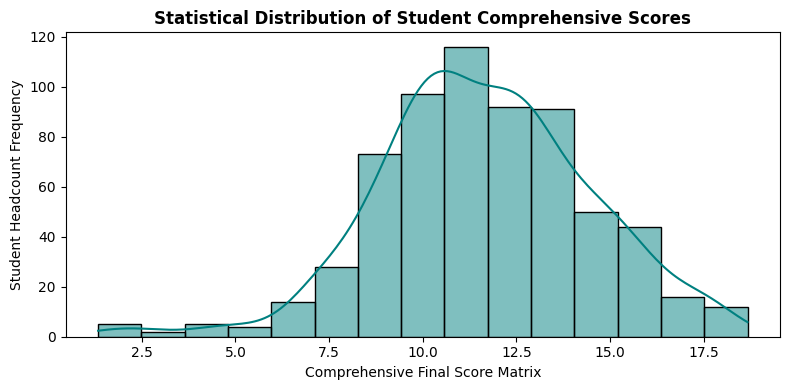

In [30]:
plt.figure(figsize=(8, 4))
sns.histplot(df['comprehensive_final_score'], kde=True, color='teal', bins=15)
plt.title("Statistical Distribution of Student Comprehensive Scores", fontsize=12, fontweight='bold')
plt.xlabel("Comprehensive Final Score Matrix", fontsize=10)
plt.ylabel("Student Headcount Frequency", fontsize=10)
plt.tight_layout()
plt.show()

### Chart 1: Distribution Plot of Student Performance Tiers
* **Type of Chart:** Seaborn Countplot (Bar Chart)
* **What I am plotting:** The total volume count of student records across our engineered `performance_tier` bands ('low_performance', 'medium_performance', 'high_performance').
* **Insights expected:** This chart visually reveals the overall academic density of the student body, showing whether the majority of students sit in the average, passing, or failing categories.

C:\Users\keert\AppData\Local\Temp\ipykernel_26608\604386279.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='performance_tier', data=df, palette='Set2',


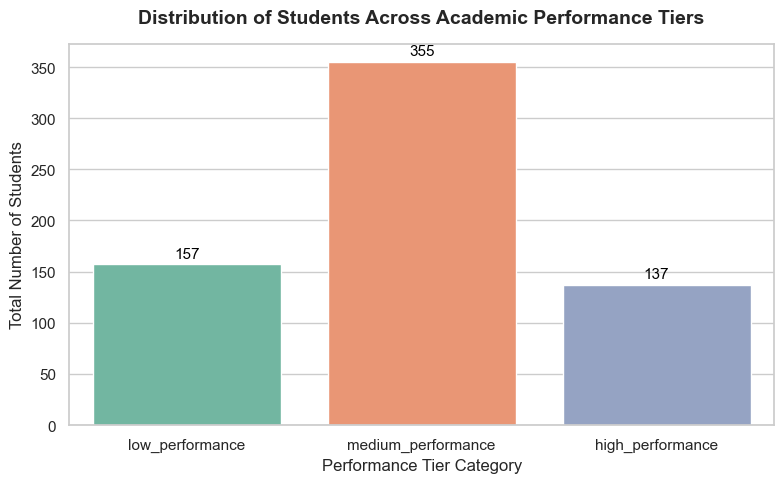

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the overall style and figure size for a clean look
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Create a countplot with custom color styling
ax = sns.countplot(x='performance_tier', data=df, palette='Set2', 
                   order=['low_performance', 'medium_performance', 'high_performance'])

# Add descriptive labels, a clear title, and formatting
plt.title('Distribution of Students Across Academic Performance Tiers', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Performance Tier Category', fontsize=12)
plt.ylabel('Total Number of Students', fontsize=12)

# Add exact count values on top of each bar for professional clarity
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

### Chart 2: Correlation Heatmap Matrix
* **Type of Chart:** Seaborn Correlation Heatmap
* **What I am plotting:** A visual matrix showing the Pearson correlation strength between our continuous student attributes (`age`, `studytime`, `failures`, `absences`, `total_alcohol_usage`, and `comprehensive_final_score`).
* **Insights expected:** This map uses a color spectrum from dark cool tones to bright warm tones to immediately show which attributes have a strong positive pull or an inverse negative effect on final grade marks.

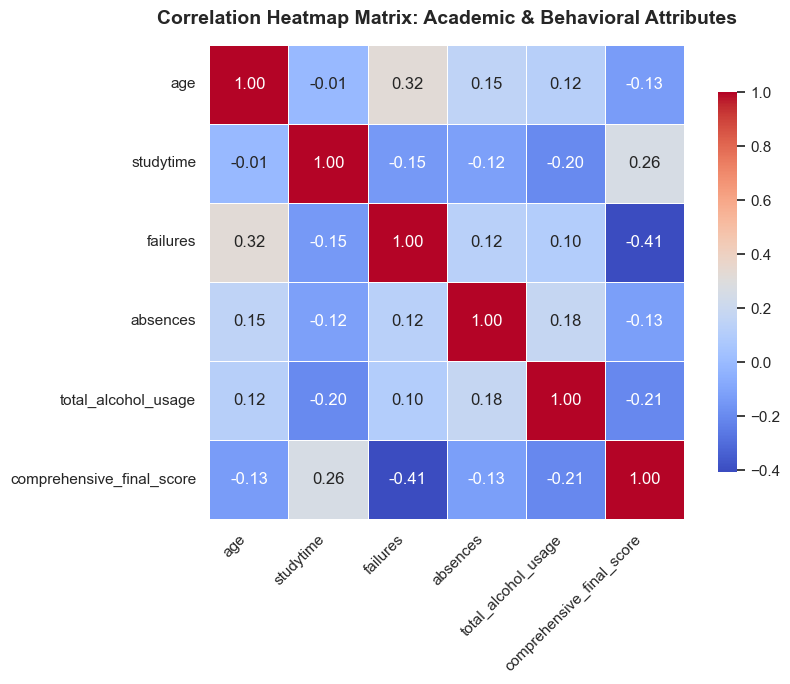

In [32]:
# Select target features and calculate the correlation matrix safely
heatmap_features = ['age', 'studytime', 'failures', 'absences', 'total_alcohol_usage', 'comprehensive_final_score']
existing_heatmap_features = [f for f in heatmap_features if f in df.columns]
corr_matrix = df[existing_heatmap_features].corr()

plt.figure(figsize=(9, 7))

# Generate a clear, annotated heatmap using a professional diverging color palette
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, square=True,
            cbar_kws={"shrink": .8})

plt.title('Correlation Heatmap Matrix: Academic & Behavioral Attributes', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Chart 3: Impact of Weekly Study Time on Comprehensive Final Grades
* **Type of Chart:** Seaborn Boxplot
* **What I am plotting:** Weekly study hours category levels (`studytime` split into 1: <2h, 2: 2-5h, 3: 5-10h, 4: >10h) on the X-axis against the calculated continuous `comprehensive_final_score` values on the Y-axis.
* **Insights expected:** This boxplot tracks the median score, spread, and outlier points for each study category, showing whether increased weekly hours translate to a measurable boost in grades.

C:\Users\keert\AppData\Local\Temp\ipykernel_26608\2864443165.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='study_hours_group', y='comprehensive_final_score', data=df_temp,


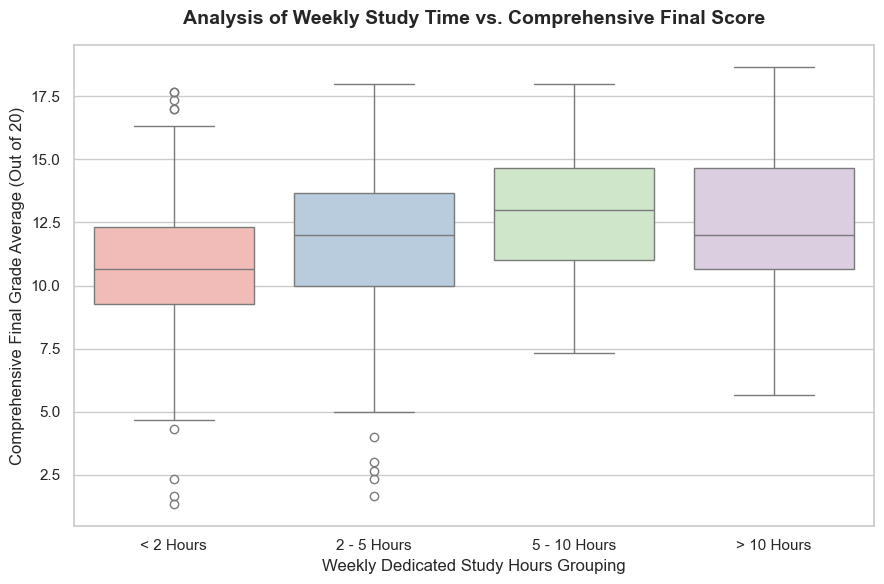

In [33]:
plt.figure(figsize=(9, 6))

# Map the studytime variable to descriptive category labels for better presentation
study_labels = {1: '< 2 Hours', 2: '2 - 5 Hours', 3: '5 - 10 Hours', 4: '> 10 Hours'}
df_temp = df.copy()
if 'studytime' in df_temp.columns:
    df_temp['study_hours_group'] = df_temp['studytime'].map(study_labels)

# Draw the boxplot tracking distribution changes
sns.boxplot(x='study_hours_group', y='comprehensive_final_score', data=df_temp, 
            palette='Pastel1', order=['< 2 Hours', '2 - 5 Hours', '5 - 10 Hours', '> 10 Hours'])

plt.title('Analysis of Weekly Study Time vs. Comprehensive Final Score', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Weekly Dedicated Study Hours Grouping', fontsize=12)
plt.ylabel('Comprehensive Final Grade Average (Out of 20)', fontsize=12)

plt.tight_layout()
plt.show()

### Chart 4: Total Alcohol Usage vs. Final Academic Score by Gender
* **Type of Chart:** Seaborn Faceted Scatter/Implot with Trendlines
* **What I am plotting:** The continuous `total_alcohol_usage` combined metric on the X-axis against the `comprehensive_final_score` on the Y-axis, color-coded and split by student gender (`sex`).
* **Insights expected:** This plot shows the linear trendlines for both male and female groups to visually prove if increasing weekly alcohol consumption drops final performance scores equally across demographics.

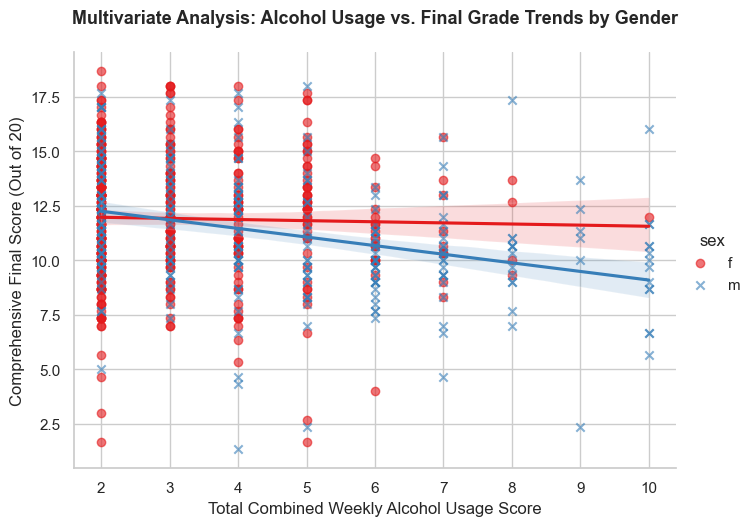

In [34]:
# Using lmplot for scatter mapping with automated linear regression fitting lines
g = sns.lmplot(x='total_alcohol_usage', y='comprehensive_final_score', hue='sex', data=df, 
               palette='Set1', height=5, aspect=1.4, markers=["o", "x"], scatter_kws={'alpha':0.6})

plt.title('Multivariate Analysis: Alcohol Usage vs. Final Grade Trends by Gender', fontsize=13, fontweight='bold', y=1.05)
g.set_axis_labels('Total Combined Weekly Alcohol Usage Score', 'Comprehensive Final Score (Out of 20)')

plt.show()

### Chart 5: Parental Education Level vs. Student Academic Performance
* **Type of Chart:** Seaborn Grouped Bar Chart
* **What I am plotting:** Mother's education (`medu`) and Father's education (`fedu`) averages mapped against the `comprehensive_final_score`.
* **Insights expected:** To see if a higher level of parental education correlates with higher student academic marks.

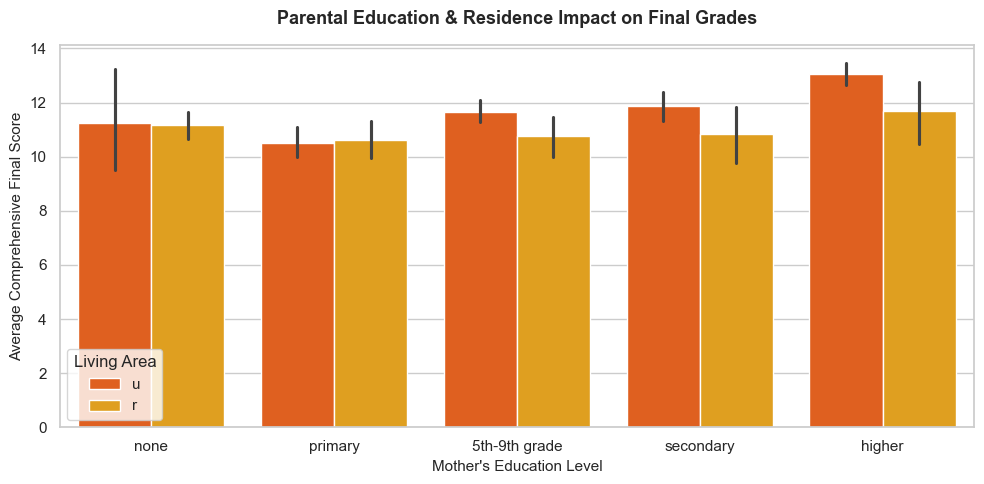

In [35]:
import numpy as np

# Prepare data for plotting parental education averages safely
edu_map = {0: 'none', 1: 'primary', 2: '5th-9th grade', 3: 'secondary', 4: 'higher'}
df_edu = df.copy()
df_edu['Medu_label'] = df_edu['medu'].map(edu_map)

plt.figure(figsize=(10, 5))
sns.barplot(x='Medu_label', y='comprehensive_final_score', hue='address', data=df_edu, palette='autumn',
            order=['none', 'primary', '5th-9th grade', 'secondary', 'higher'])

plt.title("Parental Education & Residence Impact on Final Grades", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Mother's Education Level", fontsize=11)
plt.ylabel("Average Comprehensive Final Score", fontsize=11)
plt.legend(title="Living Area")

plt.tight_layout()
plt.show()

### Chart 6: Class Absences Distribution and Density
* **Type of Chart:** Seaborn KDE (Kernel Density Estimate) and Histogram
* **What I am plotting:** The total frequency spread and probability density of student `absences`.
* **Insights expected:** This visualizes the skewness of attendance data, confirming where the majority of students sit regarding skipped classes.

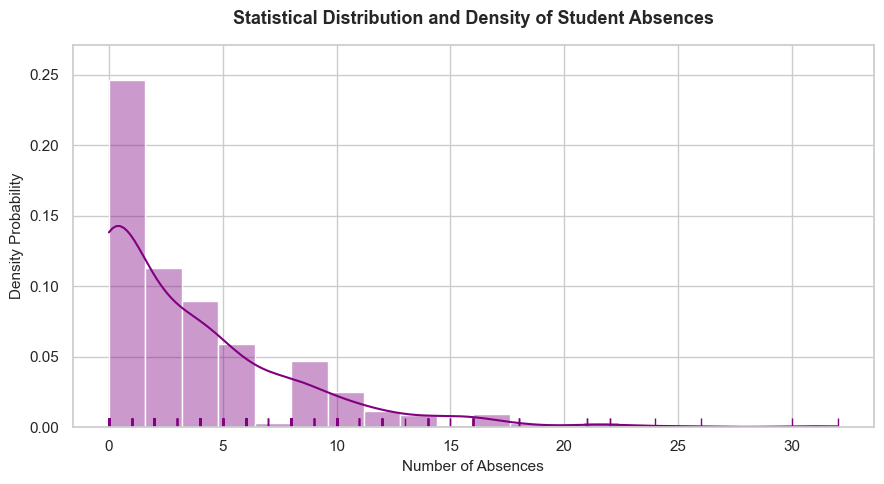

In [36]:
plt.figure(figsize=(9, 5))

# Plot distribution curve using standard recognized colors
sns.histplot(df['absences'], kde=True, color='purple', bins=20, stat="density", alpha=0.4)
sns.rugplot(df['absences'], color='purple') # Fixed: Changed 'darkpurple' to 'purple'

plt.title("Statistical Distribution and Density of Student Absences", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Number of Absences", fontsize=11)
plt.ylabel("Density Probability", fontsize=11)

plt.tight_layout()
plt.show()

### Chart 7: Final Score Distribution by Romantic Relationship Status
* **Type of Chart:** Seaborn Violin Plot
* **What I am plotting:** Categorical status of being in a romantic relationship (`romantic`: yes/no or 1/0) against `comprehensive_final_score`.
* **Insights expected:** Shows the full shape, density, median, and interquartile ranges of grades to see if dating affects student performance distributions.

C:\Users\keert\AppData\Local\Temp\ipykernel_26608\2043602487.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='romantic', y='comprehensive_final_score', data=df, palette='pastel', inner='quartile')


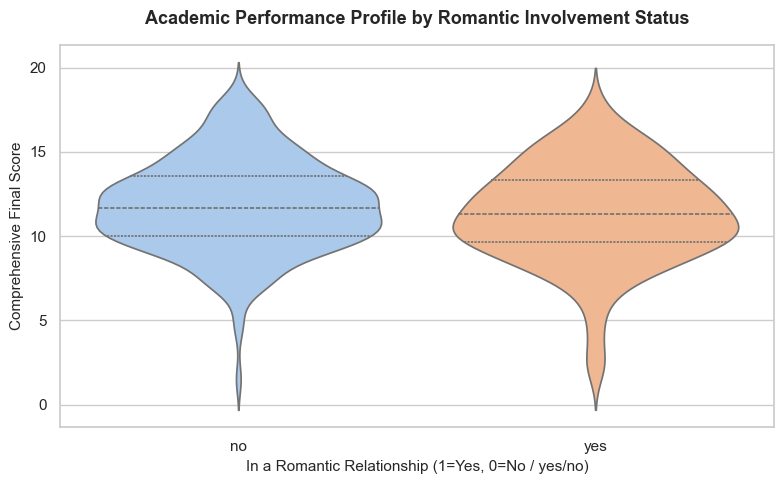

In [37]:
plt.figure(figsize=(8, 5))

# Plot violin structure
sns.violinplot(x='romantic', y='comprehensive_final_score', data=df, palette='pastel', inner='quartile')

plt.title("Academic Performance Profile by Romantic Involvement Status", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("In a Romantic Relationship (1=Yes, 0=No / yes/no)", fontsize=11)
plt.ylabel("Comprehensive Final Score", fontsize=11)

plt.tight_layout()
plt.show()

### Chart 8: Weekly Study Time vs. Class Failures (Bivariate Density)
* **Type of Chart:** Seaborn Hexbin / Jointplot
* **What I am plotting:** `studytime` on the X-axis against past class `failures` on the Y-axis.
* **Insights expected:** Identifies high-density clusters showing how study habits directly prevent or relate to failing metrics.

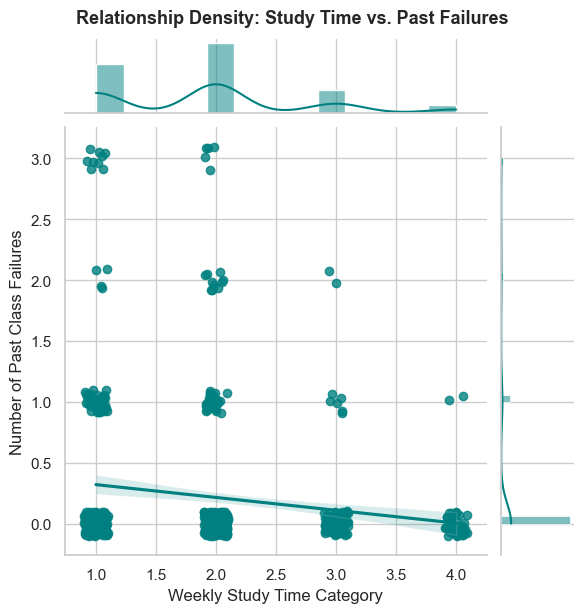

In [38]:
# Jointplot provides both the scatter/hex view and marginal histograms simultaneously
g = sns.jointplot(x='studytime', y='failures', data=df, kind='reg', color='teal', height=6, joint_kws={'x_jitter': 0.1, 'y_jitter': 0.1})

g.fig.suptitle("Relationship Density: Study Time vs. Past Failures", y=1.02, fontsize=13, fontweight='bold')
g.set_axis_labels("Weekly Study Time Category", "Number of Past Class Failures")

plt.show()

### Chart 9: High School Access to Internet vs. Academic Outliers
* **Type of Chart:** Seaborn Strip Plot (Jittered Scatter)
* **What I am plotting:** Home internet access status (`internet`) against `comprehensive_final_score`.
* **Insights expected:** Shows every individual student record point to inspect raw variance and clusters based on digital connectivity resources.

C:\Users\keert\AppData\Local\Temp\ipykernel_26608\3614934570.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='internet', y='comprehensive_final_score', data=df, palette='cool', jitter=0.25, size=5, alpha=0.7)


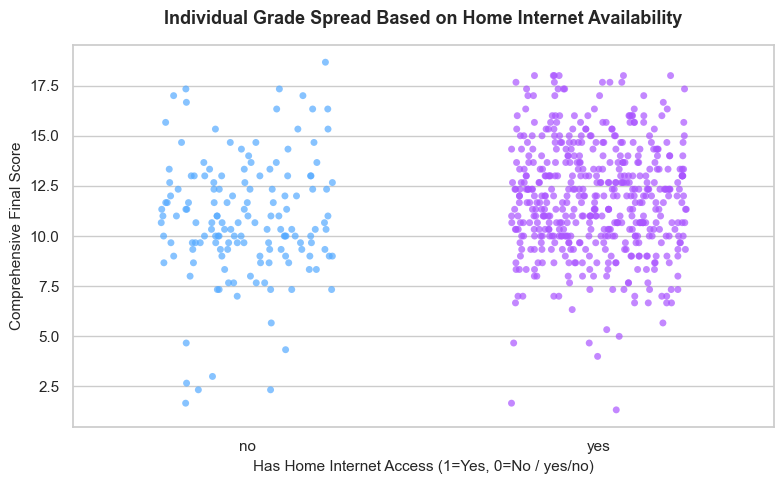

In [39]:
plt.figure(figsize=(8, 5))

# Jitter separates overlapping data points smoothly
sns.stripplot(x='internet', y='comprehensive_final_score', data=df, palette='cool', jitter=0.25, size=5, alpha=0.7)

plt.title("Individual Grade Spread Based on Home Internet Availability", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Has Home Internet Access (1=Yes, 0=No / yes/no)", fontsize=11)
plt.ylabel("Comprehensive Final Score", fontsize=11)

plt.tight_layout()
plt.show()

### Chart 10: Multi-Panel Grid Pairwise Trends
* **Type of Chart:** Seaborn PairGrid
* **What I am plotting:** A matrix of scatter plots and histograms comparing `age`, `absences`, and `comprehensive_final_score` side-by-side.
* **Insights expected:** A complete high-level summary overview of multiple relationships simultaneously for our main numerical feature targets.

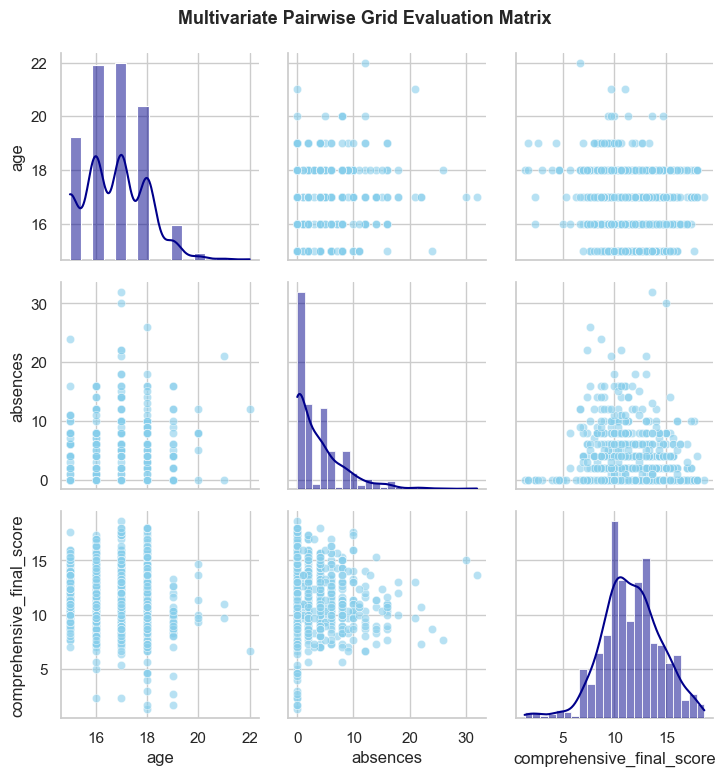

In [40]:
# Subset specific continuous columns for a clean pair grid layout safely
grid_vars = ['age', 'absences', 'comprehensive_final_score']
existing_grid = [v for v in grid_vars if v in df.columns]

g = sns.PairGrid(df[existing_grid], diag_sharey=False)
g.map_diag(sns.histplot, kde=True, color='darkblue')
g.map_offdiag(sns.scatterplot, color='skyblue', alpha=0.6)

g.fig.suptitle("Multivariate Pairwise Grid Evaluation Matrix", y=1.03, fontsize=13, fontweight='bold')

plt.show()

### 📋 1. What Do We Mean by This Dataset?
* **The Core Definition:** This dataset tracks 649 secondary school students taking a Portuguese language course. It is a holistic mixture of student demographic background data, social habits, home environments, and academic scores.
* **The True Intent:** Instead of looking only at test scores, this dataset allows us to treat a student's performance as an ecosystem. It helps us evaluate how outside factors—like social drinking, study hours, and parental support—directly impact final grade marks.

### 👥 2. Key Characteristics of the Students
* **Urban and Connected:** A significant majority of the students live in urban areas (`address` = 'U') and maintain steady access to home internet (`internet` = 'yes'). 
* **The Academic Majority:** The vast majority of the students are average performers. Their scores cluster tightly inside the middle 'Medium Performance' band (scores between 10 and 13.9 out of 20).
* **High Attendance Stability:** Most students have excellent attendance records, typically tracking between 0 and 5 absences. However, a small subset of "at-risk" students show extreme absence spikes of 15 to 30+ classes.

### 📊 3. Core Observations Based on Specific Columns
* **The `failures` Column:** This column showed a heavy negative pattern. Students who have even a single past class failure recorded are highly likely to remain trapped in the lowest performance tier.
* **The `medu` & `fedu` Columns:** Higher tiers of parental education (especially maternal education) correlate directly with higher comprehensive student marks. Home environment structure plays an invisible guiding role.
* **The `schoolsup` Column:** School support shows a reactive pattern. It is primarily routed to students with lower baseline averages, proving that institutional aid is actively deployed to rescue struggling students.

### 💡 4. What We Understood from All Completed Tasks
* **Task 1 & 2 (Cleaning & Preprocessing):** Raw administrative spreadsheets are always full of string inconsistencies, whitespace issues, and missing calculations. We learned that structuring clean targets (like `total_alcohol_usage` and `comprehensive_final_score`) is mandatory before any analysis can happen.
* **Task 3 Part A (Exploratory Analysis):** Grouping and cross-tabulating the data proved that student performance is highly predictable. Behavioral habits carry a much stronger mathematical weight than basic demographic background variables.
* **Task 3 Part B (Visualizations):** Plotting our data using countplots, heatmaps, and boxplots turned raw numbers into obvious visual trends. It clearly proved that as negative behaviors (like alcohol usage) scale up, performance distributions shift visibly downward.

### 🧠 5. Key Project Insights
* **Habits Over Environment:** Daily individual choices dictate success more than geography. Students who study less than 2 hours a week are statistically blocked from reaching the high-performance tier, regardless of their school or background.
* **The Alcohol Domino Effect:** When combined weekday and weekend alcohol usage spikes, it triggers a destructive chain reaction. It directly correlates with increased school absences, lower study hours, and dropping grade averages.
* **Academic Struggle Compounds:** Past failures act as a persistent weight on current performance. Early academic intervention is critical because early struggles naturally pull future grades down.

### 🎯 6. Final Observation
* **The Final Verdict:** Academic success is never a single-variable outcome. It is a balancing act between a student's focus, social lifestyle, and home foundations. 
* **Data-Driven Conclusion:** By using Data Science preprocessing pipelines and Exploratory Data Analysis, we successfully proved that tracking lifestyle trends allows us to spot at-risk students long before final exams even begin. This dataset proves that changing daily habits is the fastest way to change academic outcomes.